# Week 2 – Dataset Exploration and Vehicle Processing

This notebook contains the work done this week using the DRASHTI-HaOBB dataset. We first explored the annotation format and used the provided vehicle coordinates and heading angles to draw bounding boxes, show heading directions, crop individual vehicles, and convert the heading angles into orientation values. The actual orientation estimation from image pixels will be done in the next phase.



## 1. Reading the Label File

This section reads the annotation file and checks the format of the
vehicle labels.

In [10]:
with open("/content/0bGO_UHlP_zpWU.txt") as f:
    print(f.read())

flightHeight:47.09
1707 774 2022 871 2062 739 1747 642 Sedan 0 17.1
1243 1081 993 1075 990 1196 1240 1202 SUV 0 181.38
863 654 999 658 1000 607 864 603 MotorCycle 0 1.68
1567 834 1684 919 1716 875 1599 790 MotorCycle 0 36.32
1472 1053 1344 1045 1341 1092 1469 1100 MotorCycle 0 183.62
1503 1595 1503 1291 1367 1291 1367 1595 Sedan 0 270.0
1891 1133 1642 1124 1638 1250 1887 1259 SUV 0 181.88
1298 926 1384 1007 1423 967 1337 886 MotorCycle 0 43.68
2219 934 1867 946 1872 1073 2224 1061 PickUp 0 178.04
3759 1903 3697 1904 3705 2026 3767 2025 MotorCycle 0 270.0
3815 1970 3764 1971 3777 2111 3829 2109 MotorCycle 0 270.0
3573 2002 3532 2003 3538 2112 3579 2111 MotorCycle 0 270.0
3454 1939 3348 1946 3389 2151 3495 2145 SUV 0 250.0
2418 429 2670 429 2670 300 2418 300 Van 0 0.0
1659 1955 1690 2130 1799 2111 1768 1936 AutoRicksaw 0 79.9
2247 2069 2131 2046 2108 2159 2229 2159 Van 1 101.4
1764 1698 1789 1816 1844 1804 1819 1686 MotorCycle 0 77.9
1902 1497 1981 1324 1883 1280 1805 1453 AutoRicksaw 0 

## 2. Drawing Bounding Boxes and Heading

This section uses the coordinates and heading angle from the labels
to draw the vehicle boxes and heading arrows on the original image.

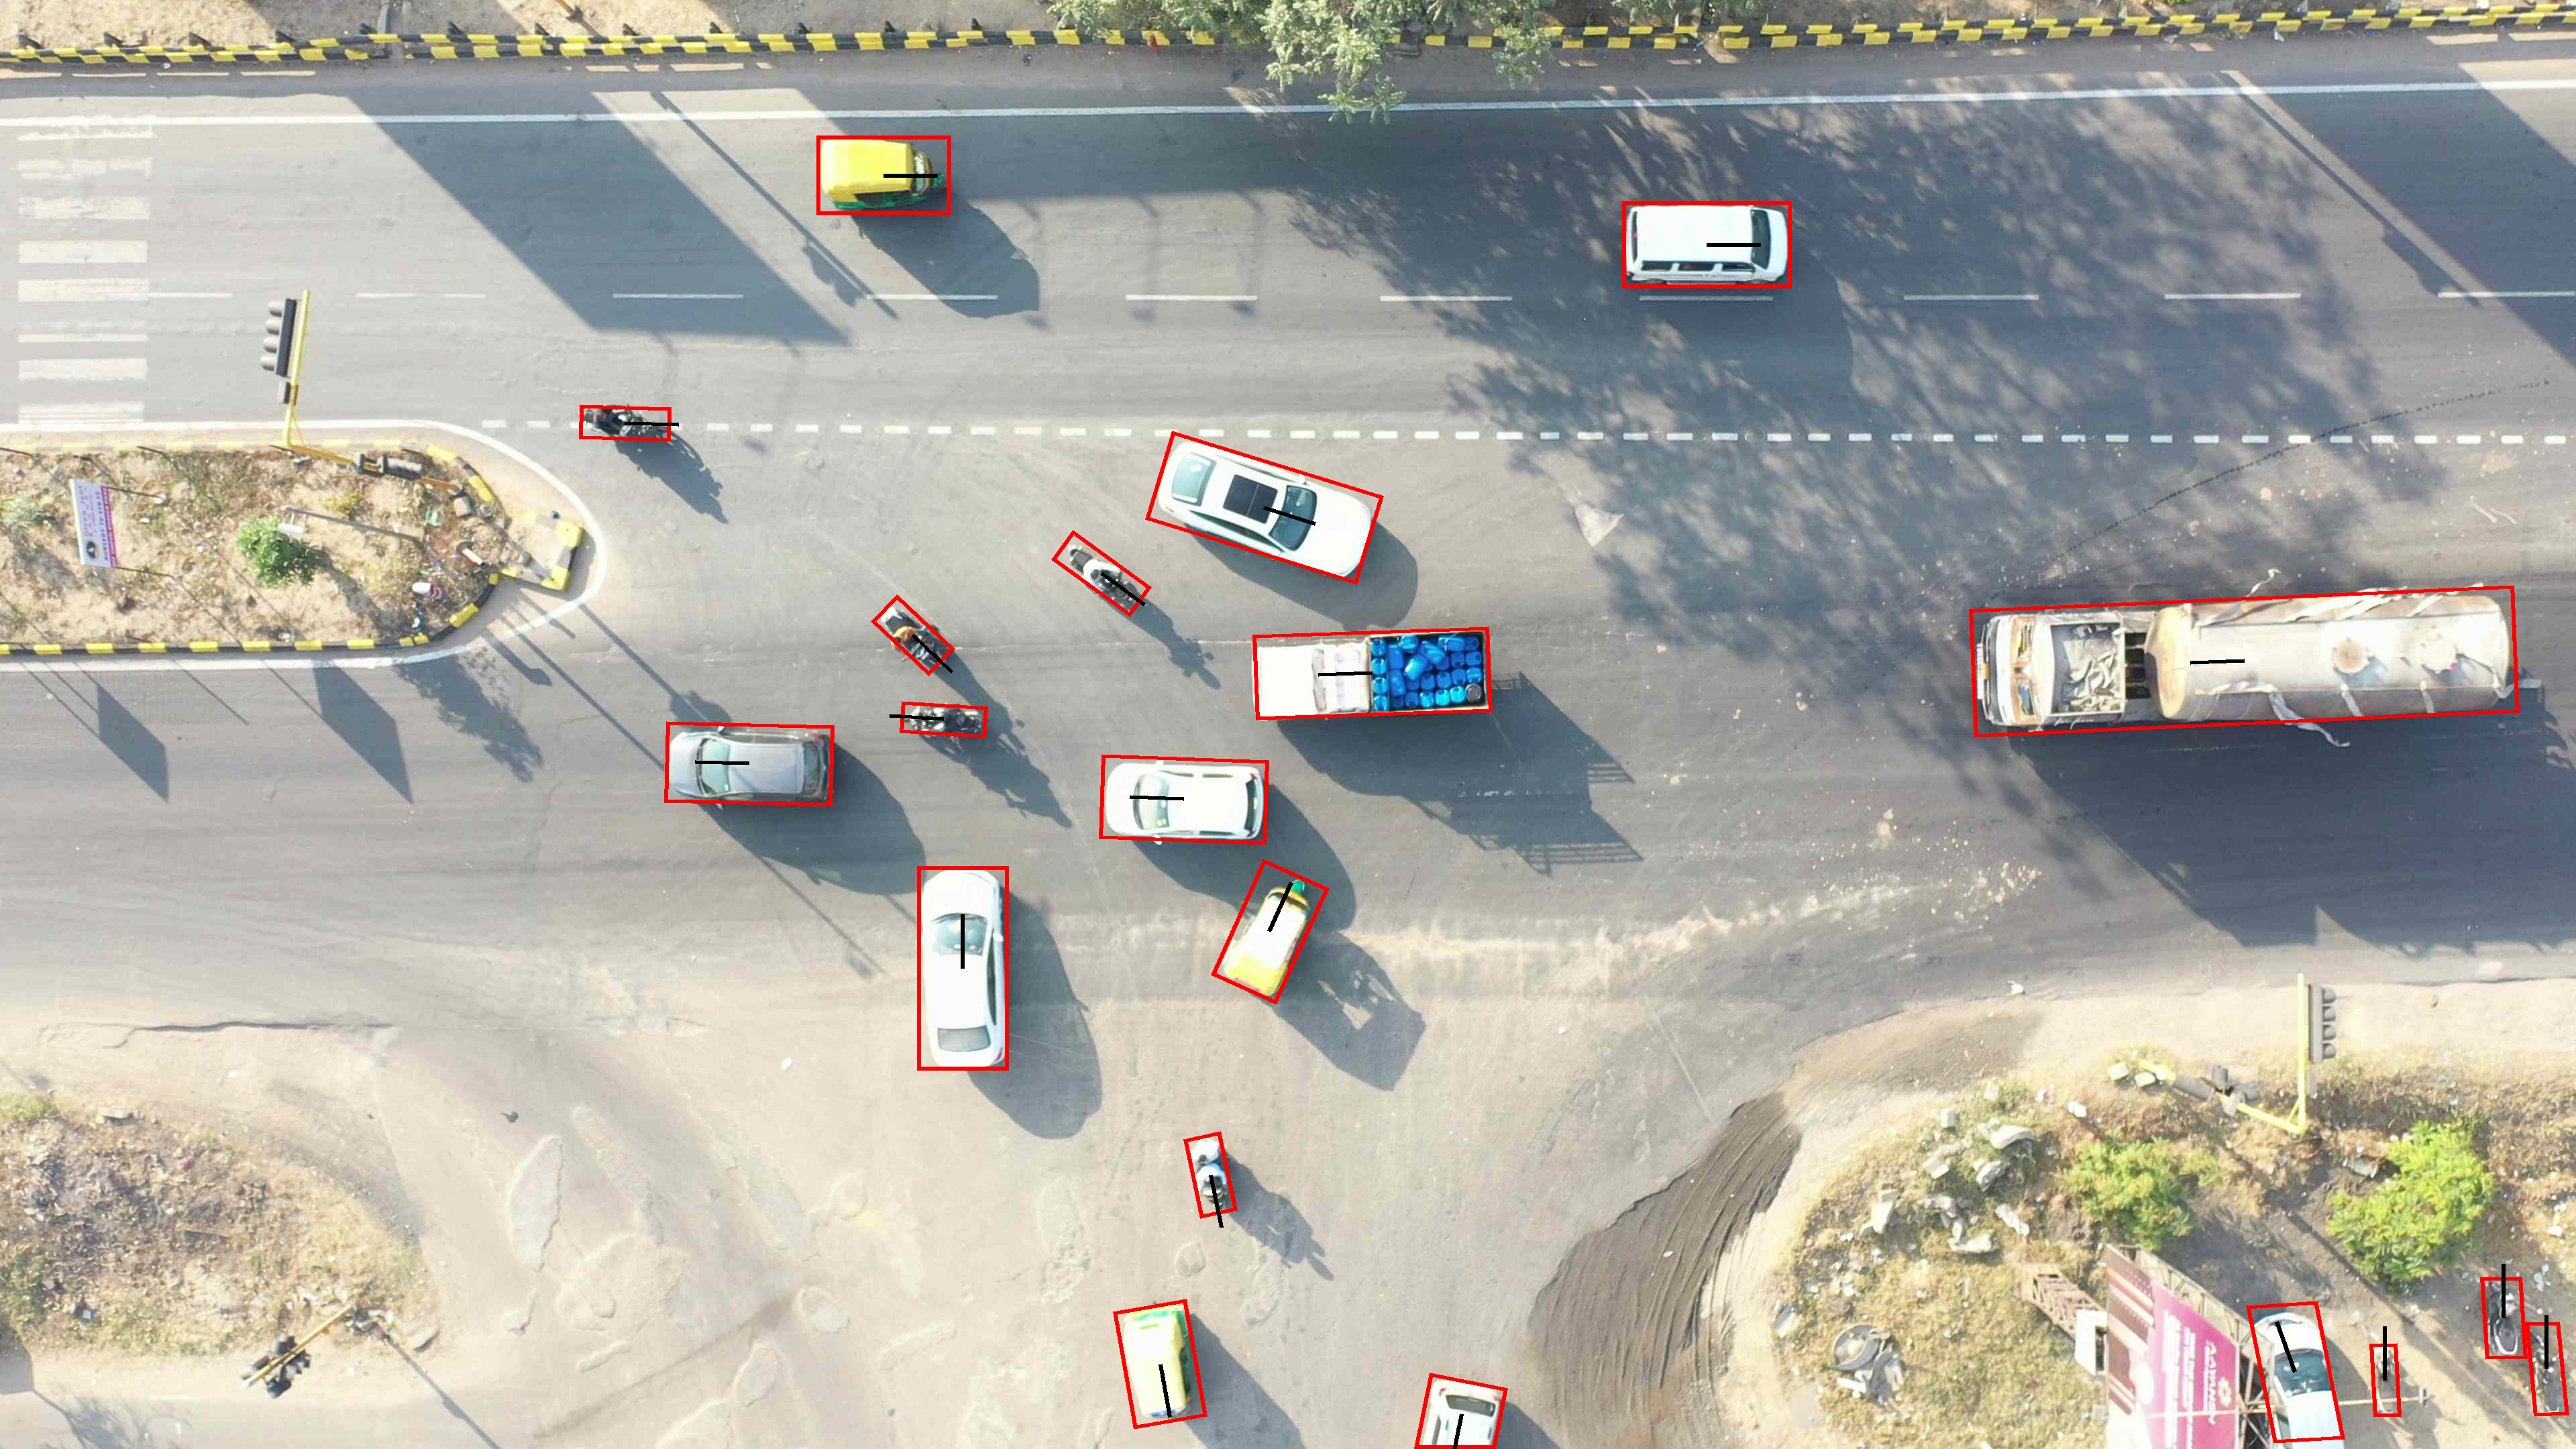

In [11]:
import math
from PIL import Image, ImageDraw

img = Image.open("0bGO_UHlP_zpWU.jpg").convert("RGB")
draw = ImageDraw.Draw(img)

with open("0bGO_UHlP_zpWU.txt") as f:
    lines = f.readlines()

for line in lines[1:]:
    parts = line.split()
    coords = list(map(float, parts[0:8]))
    points = [(coords[i], coords[i+1]) for i in range(0, 8, 2)]
    cls = parts[8]
    heading = float(parts[10])

    draw.polygon(points, outline=(255, 0, 0), width=6)

    cx = sum(p[0] for p in points) / 4
    cy = sum(p[1] for p in points) / 4
    ax = cx + 80 * math.cos(math.radians(heading))
    ay = cy + 80 * math.sin(math.radians(heading))
    draw.line([(cx, cy), (ax, ay)], fill=(0, 0, 0), width=6)

img.save("boxed_output.jpg")
img

## 3. Cropping Individual Vehicles

This section extracts each vehicle from the original image using
the coordinates in the annotation file.

In [12]:
from PIL import Image
import os

img = Image.open("0bGO_UHlP_zpWU.jpg").convert("RGB")
W, H = img.size

with open("0bGO_UHlP_zpWU.txt") as f:
    lines = f.readlines()

os.makedirs("crops", exist_ok=True)
PAD = 8

for i, line in enumerate(lines[1:], start=1):
    parts = line.split()
    coords = list(map(float, parts[0:8]))
    xs = coords[0::2]
    ys = coords[1::2]
    x_min, x_max = max(0, min(xs)-PAD), min(W, max(xs)+PAD)
    y_min, y_max = max(0, min(ys)-PAD), min(H, max(ys)+PAD)

    crop = img.crop((x_min, y_min, x_max, y_max))
    cls = parts[8]
    heading = parts[10]
    crop.save(f"crops/v{i}_{cls}_{heading}deg.jpg")

print("Saved", len(lines)-1, "vehicle crops")

Saved 20 vehicle crops


## 4. Converting Heading to Orientation

This section converts the heading angle into the orientation range
we are using for our analysis.

In [13]:
with open("0bGO_UHlP_zpWU.txt") as f:
    lines = f.readlines()

for line in lines[1:]:
    parts = line.split()
    cls = parts[8]
    heading = float(parts[10])
    orientation = round(heading % 90, 2)
    print(f"Class: {cls:<12} Heading: {heading:<8} -> Orientation: {orientation}")

Class: Sedan        Heading: 17.1     -> Orientation: 17.1
Class: SUV          Heading: 181.38   -> Orientation: 1.38
Class: MotorCycle   Heading: 1.68     -> Orientation: 1.68
Class: MotorCycle   Heading: 36.32    -> Orientation: 36.32
Class: MotorCycle   Heading: 183.62   -> Orientation: 3.62
Class: Sedan        Heading: 270.0    -> Orientation: 0.0
Class: SUV          Heading: 181.88   -> Orientation: 1.88
Class: MotorCycle   Heading: 43.68    -> Orientation: 43.68
Class: PickUp       Heading: 178.04   -> Orientation: 88.04
Class: MotorCycle   Heading: 270.0    -> Orientation: 0.0
Class: MotorCycle   Heading: 270.0    -> Orientation: 0.0
Class: MotorCycle   Heading: 270.0    -> Orientation: 0.0
Class: SUV          Heading: 250.0    -> Orientation: 70.0
Class: Van          Heading: 0.0      -> Orientation: 0.0
Class: AutoRicksaw  Heading: 79.9     -> Orientation: 79.9
Class: Van          Heading: 101.4    -> Orientation: 11.4
Class: MotorCycle   Heading: 77.9     -> Orientation: 77.9